# Chunk 10 — Path Analysis & Counterfactual Ablation
This notebook analyzes the physical features learned by the GNN (such as current path length) and performs counterfactual ablations by flipping highly-attended vs. lowly-attended pixels to measure their impact on resonance.

---
## Cell 1 — Environment Setup


In [1]:
!pip install networkx scipy tqdm


---
## Cell 2 — Mount Drive and Setup Paths


In [2]:
import os, sys
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = '/content/drive/MyDrive/antenna_gnn'
RAW_DATA  = '/content/drive/MyDrive/antenna_dataset'
REPO_ROOT = '/content/antenna-gnn'

if not os.path.exists(REPO_ROOT):
    !git clone https://github.com/asparagusD/antenna_gnn.git {REPO_ROOT}
sys.path.append(f'{REPO_ROOT}/src')

for d in [f'{DATA_ROOT}/artifacts', f'{DATA_ROOT}/checkpoints', f'{DATA_ROOT}/figures', f'{DATA_ROOT}/splits']:
    os.makedirs(d, exist_ok=True)


Mounted at /content/drive
Cloning into '/content/antenna-gnn'...
remote: Enumerating objects: 141, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 141 (delta 70), reused 119 (delta 50), pack-reused 0 (from 0)
Receiving objects: 100% (141/141), 418.59 KiB | 3.67 MiB/s, done.
Resolving deltas: 100% (70/70), done.


---
## Cell 3 — Imports and Model Loading


In [4]:
import torch
import numpy as np
import pandas as pd
import json
import networkx as nx
import matplotlib.pyplot as plt
import zipfile
import shutil
from tqdm.auto import tqdm
from scipy.signal import find_peaks

!pip install torch_geometric
from model import AntennaGNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Load standard model for ablation
model = AntennaGNN(hidden_dim=128, heads=8, edge_dim=16, num_blocks=4, output_dim=201).to(device)
ckpt = torch.load(f'{DATA_ROOT}/checkpoints/best_model.pt', map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()
print("AntennaGNN loaded.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.3 MB/s eta 0:00:00
Device: cpu
AntennaGNN loaded.


---
## Cell 4 — Path Length Computation
Calculates the physical effective path length of the metal using a Breadth-First Search (BFS) over a NetworkX graph of the metal pixels.


In [5]:
def compute_path_length_mm(patch_pattern, seed_mask, N):
    # 1. Build a NetworkX Graph (undirected) with only metal pixels
    G = nx.Graph()
    for i in range(N):
        for j in range(N):
            if patch_pattern[i, j] == 1:
                idx = i * N + j
                G.add_node(idx, pos=(i, j))
                # 4-connectivity edges (only check forward to avoid duplicates)
                if i + 1 < N and patch_pattern[i+1, j] == 1:
                    G.add_edge(idx, (i+1)*N + j)
                if j + 1 < N and patch_pattern[i, j+1] == 1:
                    G.add_edge(idx, i*N + j+1)

    # 2. Compute seed centroid
    coords = np.argwhere(seed_mask)
    if len(coords) == 0: return 0
    seed_r, seed_c = coords.mean(axis=0)

    # 3. Find the metal node closest to centroid
    min_dist = float('inf')
    feed_node = None
    for n, data in G.nodes(data=True):
        r, c = data['pos']
        dist = (r - seed_r)**2 + (c - seed_c)**2
        if dist < min_dist:
            min_dist = dist
            feed_node = n

    if feed_node is None:
        return 0

    # 4. Run BFS from feed node
    lengths = nx.single_source_shortest_path_length(G, feed_node)

    if not lengths:
        return 0

    # 5. Get maximum depth in pixels
    max_depth_pixels = max(lengths.values())

    # 6. Convert to mm
    pixel_size_mm = 32.375 / N
    return max_depth_pixels * pixel_size_mm


---
## Cell 5 — Compute Path Lengths for 25x25 Test Set
Iterates over all functioning test antennas, calculates their path length, and maps it to their actual resonant frequency.


In [9]:
LOCAL_GRAPH_ROOT = '/content/local_graphs'
N = 25
dst_dir = f'{LOCAL_GRAPH_ROOT}/{N}x{N}'
done_marker = f'{dst_dir}/_CACHED.txt'
os.makedirs(dst_dir, exist_ok=True)

if not os.path.exists(done_marker):
    # The user noted the file is in Drive at the same path structure as the repo
    zip_path = f'{DATA_ROOT}/data/processed/processed_{N}x{N}.zip'

    if not os.path.exists(zip_path):
        # Check if it's just in the DATA_ROOT directly
        zip_path = f'{DATA_ROOT}/processed_{N}x{N}.zip'

    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"Could not locate {zip_path}. Please verify the file is in your Drive at antenna_gnn/data/processed/")

    print(f"Unzipping graphs from {zip_path} to {dst_dir}")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        pt_members = [m for m in zf.namelist() if m.endswith('.pt')]
        for member in tqdm(pt_members, desc=f'{N}x{N} unzip', unit='file'):
            basename = os.path.basename(member)
            with zf.open(member) as src, open(os.path.join(dst_dir, basename), 'wb') as dst:
                shutil.copyfileobj(src, dst)
    with open(done_marker, 'w') as fh:
        fh.write('DONE\n')

# Load artifacts
s11_mean = torch.tensor(np.load(f'{DATA_ROOT}/artifacts/s11_mean.npy')).to(device)
s11_std  = torch.tensor(np.load(f'{DATA_ROOT}/artifacts/s11_std.npy')).to(device)
freq_axis = np.linspace(1.0, 4.0, 201)
seed_mask_25 = np.load(f'{DATA_ROOT}/artifacts/seed_mask_25.npy')

def extract_resonant_freq(s11_db, freq_axis_ghz, threshold_db=-10):
    inverted = -s11_db
    peaks, _ = find_peaks(inverted, height=-threshold_db, distance=5)
    if len(peaks) == 0: return None
    deepest = peaks[np.argmax(inverted[peaks])]
    return freq_axis_ghz[deepest]

with open(f'{DATA_ROOT}/splits/indices.json', 'r') as f:
    splits_all = json.load(f)
test_indices_25 = [e[1] for e in splits_all['test'] if e[0] == 25]

results = []
for idx in tqdm(test_indices_25, desc="Computing path lengths"):
    pt_path = f'{dst_dir}/sample_{idx}.pt'
    if os.path.exists(pt_path):
        data = torch.load(pt_path, weights_only=False)
        s11 = data.y.squeeze(0).cpu().numpy()
        res_freq = extract_resonant_freq(s11, freq_axis)
        if res_freq is not None:
            pattern = data.x[:N*N, 0].view(N, N).cpu().numpy()
            l_mm = compute_path_length_mm(pattern, seed_mask_25, N)
            results.append({'path_length_mm': l_mm, 'res_freq_ghz': res_freq})

df = pd.DataFrame(results)
csv_path = f'{DATA_ROOT}/artifacts/path_length_data_25x25.csv'
df.to_csv(csv_path, index=False)
print(f"Processed {len(df)} functioning antennas. Saved to {csv_path}")

Unzipping graphs from /content/drive/MyDrive/antenna_gnn/data/processed/processed_25x25.zip to /content/local_graphs/25x25


25x25 unzip:   0%|          | 0/99833 [00:00<?, ?file/s]

Computing path lengths:   0%|          | 0/9983 [00:00<?, ?it/s]

Processed 5489 functioning antennas. Saved to /content/drive/MyDrive/antenna_gnn/artifacts/path_length_data_25x25.csv


---
## Cell 6 — Scatter Plot: Path Length vs Resonant Frequency
We plot the true resonant frequency against the calculated geometric path length and overlay the theoretical formula $f = c / (2 L_{eff})$.


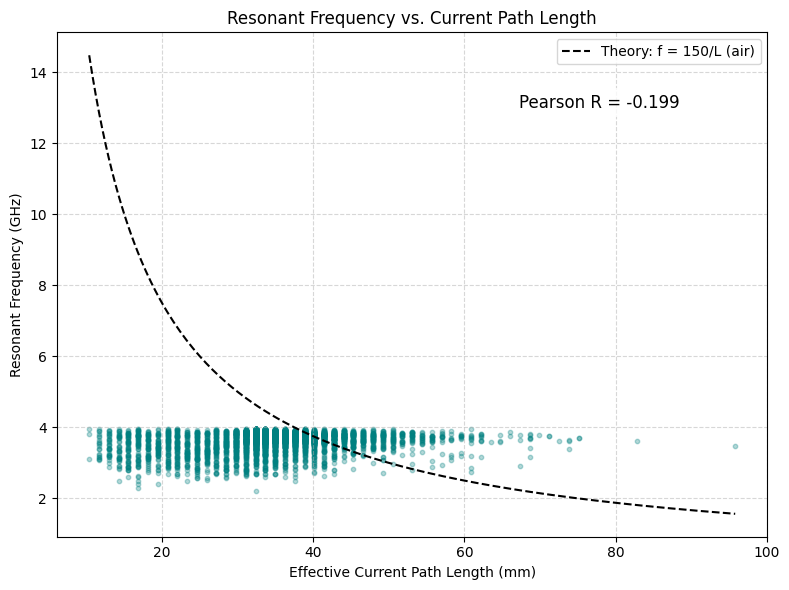

Saved scatter plot to /content/drive/MyDrive/antenna_gnn/figures/path_length_vs_freq.png


In [10]:
from scipy.stats import pearsonr

plt.figure(figsize=(8, 6))
plt.scatter(df['path_length_mm'], df['res_freq_ghz'], color='teal', alpha=0.3, s=10)
plt.xlabel('Effective Current Path Length (mm)')
plt.ylabel('Resonant Frequency (GHz)')

# Theoretical curve: f = 150 / L
L_theory = np.linspace(df['path_length_mm'].min(), df['path_length_mm'].max(), 200)
L_theory = L_theory[L_theory > 0] # Avoid division by zero
f_theory = 150 / L_theory
plt.plot(L_theory, f_theory, 'k--', label='Theory: f = 150/L (air)')

# Correlation between L and 1/f
r, _ = pearsonr(df['path_length_mm'], 1 / df['res_freq_ghz'])
plt.text(0.65, 0.85, f'Pearson R = {r:.3f}', transform=plt.gca().transAxes,
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.title('Resonant Frequency vs. Current Path Length')
plt.tight_layout()

save_path = f'{DATA_ROOT}/figures/path_length_vs_freq.png'
plt.savefig(save_path, dpi=300)
plt.show()
print(f"Saved scatter plot to {save_path}")


---
## Cell 7 — Counterfactual Ablation Setup
We find the 10 highest-attention metal pixels (the "current path") and 10 low-attention metal pixels that are at a similar distance from the feed. These define our ablation sets.


In [11]:
from torch_geometric.nn import global_mean_pool

# Redefine AttentionGNN from Chunk 9
class AttentionGNN(AntennaGNN):
    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        batch = data.batch

        x = self.input_proj(x)
        edge_attr = self.edge_proj(edge_attr)

        attn_tuple = None
        for i, block in enumerate(self.blocks):
            for j, layer in enumerate(block):
                if i == len(self.blocks) - 1 and j == len(block) - 1:
                    conv_out, attn_tuple = layer.conv(x, edge_index, edge_attr=edge_attr, return_attention_weights=True)
                    out = layer.norm(conv_out)
                    x = layer.act(out + layer.residual_proj(x))
                else:
                    x = layer(x, edge_index, edge_attr)

        metal_mask = data.x[:, 0] > 0.5
        metal_x = x[metal_mask]
        metal_batch = batch[metal_mask]
        pooled = global_mean_pool(metal_x, metal_batch)

        virtual_mask = data.x[:, 3] == -1
        virtual_x = x[virtual_mask]

        combined = torch.cat([pooled, virtual_x], dim=-1)
        out = self.readout_proj(combined)
        out = self.output_mlp(out)

        return out, attn_tuple

attn_model = AttentionGNN(hidden_dim=128, heads=8, edge_dim=16, num_blocks=4, output_dim=201).to(device)
attn_model.load_state_dict(ckpt['model_state'])
attn_model.eval()

def get_attention_map(data, model, N):
    data = data.to(device)
    with torch.no_grad():
        out, (attn_edge_index, attn_weights) = model(data)
    edge_scores = attn_weights.mean(dim=1).cpu()
    attn_edge_index = attn_edge_index.cpu()
    attention_grid = np.zeros(N * N)
    is_metal = data.x[:N*N, 0].cpu().numpy() > 0.5
    for i in range(N * N):
        if is_metal[i]:
            target_mask = (attn_edge_index[1] == i)
            if target_mask.any():
                attention_grid[i] = edge_scores[target_mask].mean().item()
    attention_grid = attention_grid.reshape(N, N)
    min_val, max_val = attention_grid.min(), attention_grid.max()
    if max_val > min_val:
        attention_grid = (attention_grid - min_val) / (max_val - min_val)
    return attention_grid

# Select 20 random functioning antennas
np.random.seed(42)
selected_indices = np.random.choice(test_indices_25, 200, replace=False)

func_graphs = []
for idx in selected_indices:
    pt_path = f'{LOCAL_GRAPH_ROOT}/25x25/sample_{idx}.pt'
    data = torch.load(pt_path, weights_only=False)
    s11 = data.y.squeeze(0).cpu().numpy()
    if extract_resonant_freq(s11, freq_axis) is not None:
        func_graphs.append(data)
    if len(func_graphs) == 20:
        break

ablation_tasks = []
coords = np.argwhere(seed_mask_25)
seed_r, seed_c = coords.mean(axis=0)

for data in func_graphs:
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
    attn_grid = get_attention_map(data, attn_model, N)
    pattern = data.x[:N*N, 0].view(N, N).cpu().numpy()

    # Compute distances
    dist_grid = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            dist_grid[i, j] = np.sqrt((i - seed_r)**2 + (j - seed_c)**2)

    # Metal pixels outside seed
    valid_metal = (pattern == 1) & (seed_mask_25 == 0)
    metal_indices = np.argwhere(valid_metal)

    # Convert argwhere to tuples for easier lookup
    metal_tuples = [tuple(x) for x in metal_indices]
    scores = [attn_grid[r, c] for r, c in metal_tuples]

    # Top 10 path pixels
    top_10_idx = np.argsort(scores)[-10:]
    path_pixels = [metal_tuples[i] for i in top_10_idx]

    # Calculate their distances
    path_dists = [dist_grid[r, c] for r, c in path_pixels]
    mean_dist = np.mean(path_dists)

    # Find low attention pixels at similar distance
    dist_mask = (dist_grid >= mean_dist * 0.8) & (dist_grid <= mean_dist * 1.2)
    valid_offpath = valid_metal & dist_mask
    offpath_indices = np.argwhere(valid_offpath)

    if len(offpath_indices) >= 10:
        offpath_tuples = [tuple(x) for x in offpath_indices]
        offpath_scores = [attn_grid[r, c] for r, c in offpath_tuples]
        bottom_10_idx = np.argsort(offpath_scores)[:10]
        offpath_pixels = [offpath_tuples[i] for i in bottom_10_idx]
    else:
        bottom_10_idx = np.argsort(scores)[:10]
        offpath_pixels = [metal_tuples[i] for i in bottom_10_idx]

    s11 = data.y.squeeze(0).cpu().numpy()
    orig_f = extract_resonant_freq(s11, freq_axis)

    ablation_tasks.append({
        'pattern': pattern,
        'orig_f': orig_f,
        'path_pixels': path_pixels,
        'offpath_pixels': offpath_pixels
    })

print(f"Prepared {len(ablation_tasks)} antennas for ablation.")


Prepared 20 antennas for ablation.


---
## Cell 8 — Counterfactual Forward Passes
We systematically flip one pixel at a time (from metal to air), rebuild the PyG graph, and pass it through the model. We record how much the predicted resonant frequency shifts (`|Δ Resonant Frequency|`).


In [13]:
from torch_geometric.data import Data

def build_pyg_graph(patch_pattern, seed_mask, N):
    coords = np.argwhere(seed_mask)
    seed_r, seed_c = coords.mean(axis=0)

    node_feats = []
    for i in range(N):
        for j in range(N):
            metal    = float(patch_pattern[i, j])
            x_norm   = j / (N - 1)
            y_norm   = i / (N - 1)
            is_seed  = float(seed_mask[i, j])
            dist_f   = np.sqrt((i - seed_r)**2 + (j - seed_c)**2) / N
            node_feats.append([metal, x_norm, y_norm, is_seed, dist_f])

    # Fix: The virtual node marker (index 3) must be -1.0 for the model to find it
    node_feats.append([0.0, 0.5, 0.5, -1.0, 0.0])
    node_feats = torch.tensor(node_feats, dtype=torch.float)

    edge_src, edge_dst, edge_attr = [], [], []
    etype_map = {(1,1):0, (1,0):1, (0,1):2, (0,0):3}
    for i in range(N):
        for j in range(N):
            idx = i * N + j
            m_ij = int(patch_pattern[i, j])
            for (di, dj, direction) in [(0,1,0),(0,-1,1),(-1,0,2),(1,0,3)]:
                ni, nj = i+di, j+dj
                if 0 <= ni < N and 0 <= nj < N:
                    nidx = ni * N + nj
                    m_nb = int(patch_pattern[ni, nj])
                    etype = etype_map[(m_ij, m_nb)]
                    edge_src.append(idx); edge_dst.append(nidx)
                    edge_attr.append([etype, direction])

    global_idx = N * N
    for i in range(N):
        for j in range(N):
            if patch_pattern[i, j] == 1:
                idx = i * N + j
                edge_src += [global_idx, idx]
                edge_dst += [idx, global_idx]
                edge_attr += [[4, 4], [4, 4]]

    edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
    edge_attr  = torch.tensor(edge_attr, dtype=torch.float)
    batch = torch.zeros(N * N + 1, dtype=torch.long)

    return Data(x=node_feats, edge_index=edge_index, edge_attr=edge_attr, batch=batch)

path_pixel_deltas = []
offpath_pixel_deltas = []

for task in tqdm(ablation_tasks, desc="Ablating antennas"):
    orig_pat = task['pattern']
    orig_f = task['orig_f']

    # Evaluate path pixels
    for r, c in task['path_pixels']:
        mod_pat = orig_pat.copy()
        mod_pat[r, c] = 0 # flip to air
        data = build_pyg_graph(mod_pat, seed_mask_25, 25).to(device)
        with torch.no_grad():
            out = model(data)
        pred_s11 = (out.cpu() * s11_std.cpu() + s11_mean.cpu()).numpy().flatten()
        mod_f = extract_resonant_freq(pred_s11, freq_axis)

        delta = abs(mod_f - orig_f) if mod_f is not None else orig_f
        path_pixel_deltas.append(delta)

    # Evaluate off-path pixels
    for r, c in task['offpath_pixels']:
        mod_pat = orig_pat.copy()
        mod_pat[r, c] = 0
        data = build_pyg_graph(mod_pat, seed_mask_25, 25).to(device)
        with torch.no_grad():
            out = model(data)
        pred_s11 = (out.cpu() * s11_std.cpu() + s11_mean.cpu()).numpy().flatten()
        mod_f = extract_resonant_freq(pred_s11, freq_axis)

        delta = abs(mod_f - orig_f) if mod_f is not None else orig_f
        offpath_pixel_deltas.append(delta)

print(f"Evaluated {len(path_pixel_deltas)} path pixel flips and {len(offpath_pixel_deltas)} off-path pixel flips.")

Ablating antennas:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluated 200 path pixel flips and 200 off-path pixel flips.


---
## Cell 9 — Box Plot and Statistical Test
We visualize the ablation results to confirm that removing highly-attended pixels causes a much larger disruption to the resonant frequency than removing low-attention pixels, thereby confirming that the GATv2 model has physically learned the "current path".


/tmp/ipykernel_897/2940201140.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(box_data, labels=labels, patch_artist=True, widths=0.5)


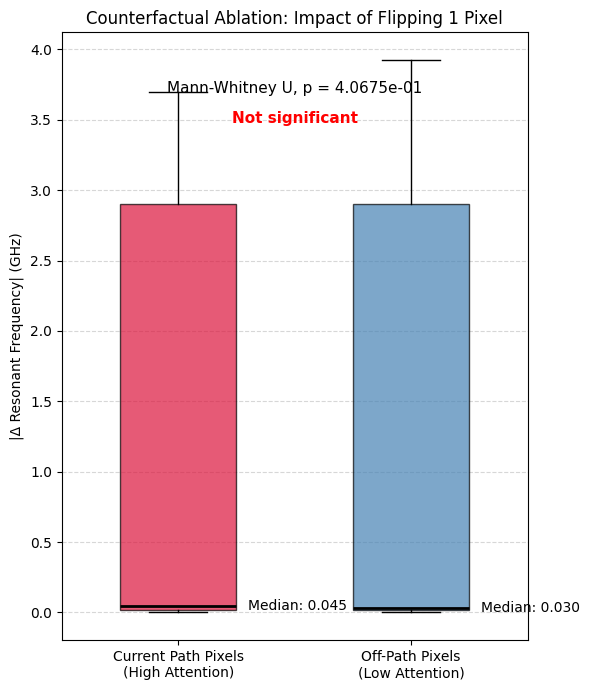

Median path delta:     0.0450 GHz
Median off-path delta: 0.0300 GHz
Ratio:                 1.50x
p-value:               4.0675e-01


In [14]:
from scipy.stats import mannwhitneyu

plt.figure(figsize=(6, 7))

box_data = [path_pixel_deltas, offpath_pixel_deltas]
labels = ['Current Path Pixels\n(High Attention)', 'Off-Path Pixels\n(Low Attention)']

bplot = plt.boxplot(box_data, labels=labels, patch_artist=True, widths=0.5)

colors = ['crimson', 'steelblue']
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for median in bplot['medians']:
    median.set_color('black')
    median.set_linewidth(2)

# Mann-Whitney U test
stat, pval = mannwhitneyu(path_pixel_deltas, offpath_pixel_deltas, alternative='greater')

plt.ylabel('|Δ Resonant Frequency| (GHz)')
plt.title('Counterfactual Ablation: Impact of Flipping 1 Pixel')

p_text = f'Mann-Whitney U, p = {pval:.4e}'
sig_text = 'Statistically significant (p < 0.05)' if pval < 0.05 else 'Not significant'
color = 'green' if pval < 0.05 else 'red'

plt.text(0.5, 0.90, p_text, transform=plt.gca().transAxes, ha='center', fontsize=11)
plt.text(0.5, 0.85, sig_text, transform=plt.gca().transAxes, ha='center', fontsize=11, color=color, fontweight='bold')

med_path = np.median(path_pixel_deltas)
med_offpath = np.median(offpath_pixel_deltas)
plt.text(1.3, med_path, f'Median: {med_path:.3f}', va='center')
plt.text(2.3, med_offpath, f'Median: {med_offpath:.3f}', va='center')

plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

save_path = f'{DATA_ROOT}/figures/counterfactual_ablation.png'
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Median path delta:     {med_path:.4f} GHz")
print(f"Median off-path delta: {med_offpath:.4f} GHz")
print(f"Ratio:                 {med_path/med_offpath if med_offpath>0 else float('inf'):.2f}x")
print(f"p-value:               {pval:.4e}")
